In [1]:
from analysis.batch_intrinsics import collect_intrinsics
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = collect_intrinsics("dvmn")

[compute] fre025/fre025_ss41068-gfp_20260417_121409_metadata.json -> fre025_ss41068-gfp_20260417_121409_intrinsics.csv + fre025_ss41068-gfp_20260417_121409_step_rates.csv
No stimulus events found. Falling back to waveform detection.
No step_protocols detected in this recording.

collect_intrinsics: 11 matched recording(s) (10 cached, 0 computed, 1 error)


In [3]:
csv_paths = df.query("status != 'error'")["intrinsics_csv_path"].tolist()
h5_paths = df.query("status != 'error'")["h5_path"].tolist()

In [4]:
h5_paths

['D:\\data\\fre019\\fre019_ss31997-gfp_20260402_110453.h5',
 'D:\\data\\fre021\\fre021_ss41068-gfp_20260408_121052.h5',
 'D:\\data\\fre024\\fre024_ss31997-gfp_20260416_113834.h5',
 'D:\\data\\fre024\\fre024_ss31997-gfp_20260416_114622.h5',
 'D:\\data\\fre025\\fre025_ss41068-gfp_20260417_115827.h5',
 'D:\\data\\fre025\\fre025_ss41068-gfp_20260417_121426.h5',
 'D:\\data\\fre054\\fre054_ss31950-gfp_20260720_103504.h5',
 'D:\\data\\fre060\\fre060_ss31950-gfp_20260803_125000.h5',
 'D:\\data\\fre071\\fre071_ss31950-gfp_20260915_164220.h5',
 'D:\\data\\fre071\\fre071_ss31950-gfp_20260915_165036.h5']

In [5]:
rmp_summary = []
rinput_summary = []
for path in csv_paths:
    intrinsic_df = pd.read_csv(path)
    if intrinsic_df.rmp_mV.mean() > -40:
        print(path + ": " + str(intrinsic_df.rmp_mV.mean()) +", "+ str(intrinsic_df.input_resistance_MOhm.mean()))
    rmp_summary.append(intrinsic_df.rmp_mV.median())
    rinput_summary.append(intrinsic_df.input_resistance_MOhm.median())
    


D:\results\csv\fre019_ss31997-gfp_20260402_110453_intrinsics.csv: -38.62499999999999, 443.04166666666674
D:\results\csv\fre054_ss31950-gfp_20260720_103504_intrinsics.csv: -37.93999999999999, 122.61999999999998


(-70.0, -30.0)

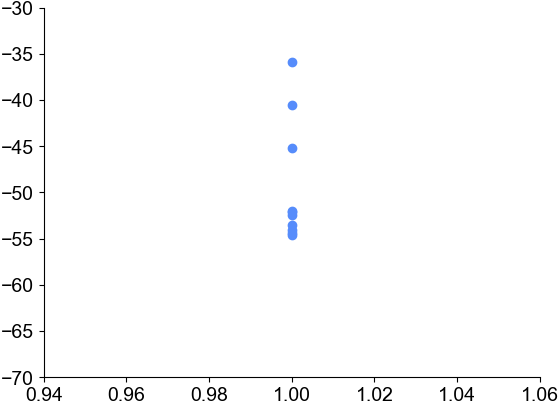

In [6]:
plt.scatter(np.ones(len(rmp_summary)), rmp_summary)
plt.ylim(-70,-30)

(50.0, 800.0)

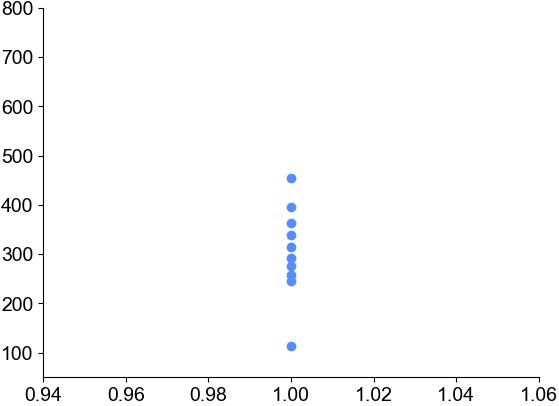

In [7]:
plt.scatter(np.ones(len(rinput_summary)), rinput_summary)
plt.ylim(50,800)

control (n=6) — recordings per amplitude: {-100: 4, -50: 5, -40: 3, -30: 3, -25: 2, -20: 3, -10: 3, 10: 3, 20: 3, 25: 2, 30: 3, 40: 3, 50: 5, 75: 1, 100: 5, 125: 1, 150: 4, 200: 3, 250: 1, 300: 3}
caffeine (n=1) — recordings per amplitude: {-100: 1, -50: 1, 50: 1, 100: 1}
octopamine (n=3) — recordings per amplitude: {-100: 2, -50: 3, 50: 3, 100: 3, 150: 2, 200: 2, 300: 1, 400: 1}


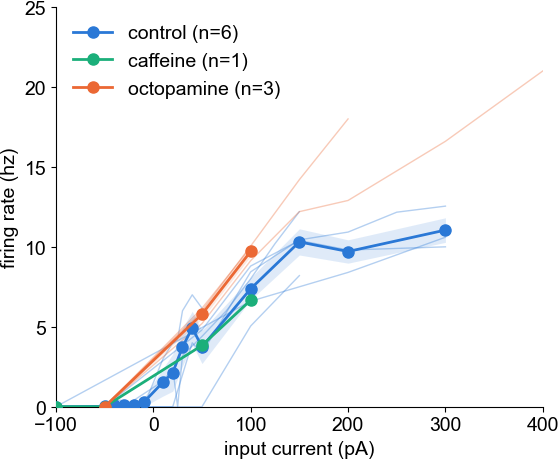

In [10]:
# ── F-I curves, split by drug condition ──────────────────────────────────
# Firing rate vs injected current: thin lines are individual recordings,
# bold lines the per-condition mean ± SEM.  Color encodes condition, which
# is the comparison worth making; individual recordings within a condition
# are replicates and are not told apart.
#
# Grouping is by drug_name rather than a binary drug/control flag, because
# octopamine and caffeine are different manipulations and pooling them
# would hide the thing the split is for.  To collapse to binary instead:
#     ok["condition"] = np.where(ok["drug_applied"].str.lower() == "true",
#                                "drug", "control")
#
# CAVEATS
#  1. Recordings used different step grids (10 / 25 / 50 pA), so a pooled
#     point can rest on a different subset of cells than its neighbour —
#     non-monotonic wiggles may be composition, not physiology.
#     MIN_RECORDINGS_PER_POINT is the knob; the printout reports coverage.
#  2. SEM bands are drawn only where a condition has >= 2 recordings at that
#     amplitude, so a single-recording condition shows a bare line.
#  3. Firing rate is quantised: 500 ms steps mean rate = n_spikes x 2, so
#     the resolution is 2 Hz and one spike reads as 2 Hz.  If the shape of
#     the high-current end matters, longer steps buy more than any amount
#     of detector tuning.
#  4. Spike detection is adaptive: the trace is detrended, the prominence
#     bar is scaled to that trace's own noise (floored at 2.5 mV), and a
#     rate-of-rise bar rejects slow humps and transition artifacts.  This
#     recovers attenuated APs under strong injection that the previous
#     fixed 7 mV floor missed entirely — fre071 at 300 pA went 1.4 -> 10.0
#     Hz — so the right-hand end of these curves is no longer biased low.
#     The 2.5 mV floor sits just under the smallest real AP in the dataset
#     (3.1 mV), so anything genuinely smaller is undetectable by design.

MIN_RECORDINGS_PER_POINT = 3

GROUP_COLORS = {"control": "#2a78d6", "octopamine": "#eb6834", "caffeine": "#1baf7a"}
FALLBACK_COLOR = "#898781"

ok = df.query("status != 'error'").copy()
ok["condition"] = (
    ok["drug_name"].fillna("").str.strip().str.lower().replace("", "control")
)

curves = {}
for _, row in ok.iterrows():
    rates = pd.read_csv(row["step_rates_csv_path"])
    if rates.empty:
        continue
    curves[row["h5_path"]] = (
        rates.assign(amp=rates["amplitude_pA"].round(0).astype(int))
        .groupby("amp")["firing_rate_hz"]
        .mean()
    )

fi = pd.DataFrame(curves).sort_index()   # rows: amplitude, cols: recording
cond_of = dict(zip(ok["h5_path"], ok["condition"]))
order = ["control"] + sorted(c for c in ok["condition"].unique() if c != "control")

fig, ax = plt.subplots(figsize=(6.0, 5.0))

for cond in order:
    cols = [c for c in fi.columns if cond_of.get(c) == cond]
    if not cols:
        continue
    color = GROUP_COLORS.get(cond, FALLBACK_COLOR)
    sub = fi[cols]

    for c in cols:
        s = sub[c].dropna()
        ax.plot(s.index, s.values, color=color, lw=1.0, alpha=0.35, zorder=1)

    n_per_amp = sub.notna().sum(axis=1)
    pooled = sub[n_per_amp >= min(MIN_RECORDINGS_PER_POINT, len(cols))]
    if pooled.empty:
        continue
    n = pooled.notna().sum(axis=1)
    mean = pooled.mean(axis=1)
    band = (pooled.std(axis=1) / np.sqrt(n)).where(n >= 2)   # no SEM from n=1
    ax.fill_between(mean.index, mean - band, mean + band,
                    color=color, alpha=0.15, lw=0, zorder=2)
    ax.plot(mean.index, mean.values, color=color, lw=2.0,
            marker="o", markersize=8, zorder=3, label=f"{cond} (n={len(cols)})")

ax.set_xlabel("input current (pA)")
ax.set_ylabel("firing rate (hz)")
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()

for cond in order:
    cols = [c for c in fi.columns if cond_of.get(c) == cond]
    n = fi[cols].notna().sum(axis=1)
    covered = {int(a): int(v) for a, v in n[n > 0].items()}
    print(f"{cond} (n={len(cols)}) — recordings per amplitude: {covered}")

10 recordings pooled; mean drawn over 15 amplitudes with n >= 3 (n range 3-9)


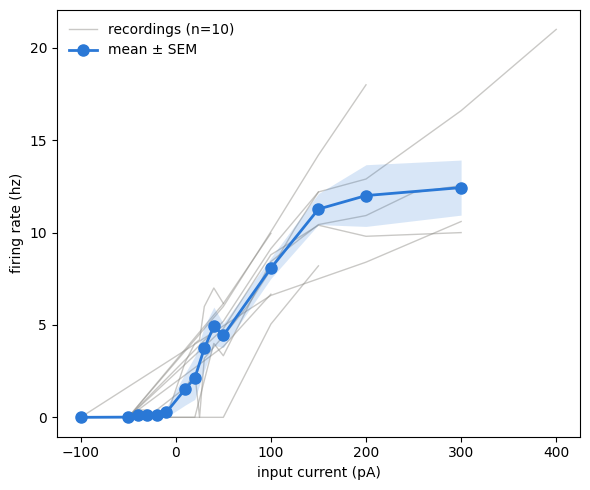

In [11]:
# ── F-I curve, all recordings pooled ─────────────────────────────────────
# The same data as the cell above with the condition split collapsed: one
# thin line per recording, one mean ± SEM across all of them.  Reuses `fi`
# from the cell above, so run that first.
#
# Recording identity is not encoded here — the spread is the point — so
# the individual lines share one neutral color rather than ten competing
# hues.
#
# Caveats 1, 3 and 4 from the cell above apply unchanged.  One more that
# is specific to pooling: this mixes 4 drug recordings (3 octopamine, 1
# caffeine) with 6 controls, and the split above shows octopamine sitting
# well above control across the whole range.  The pooled mean is a
# description of this set of recordings, not of a single condition.

POOLED_MIN_RECORDINGS = 3

MUTED = "#898781"
ACCENT = "#2a78d6"

n_per_amp = fi.notna().sum(axis=1)
pooled_all = fi[n_per_amp >= POOLED_MIN_RECORDINGS]
n = pooled_all.notna().sum(axis=1)
pooled_mean = pooled_all.mean(axis=1)
pooled_sem = (pooled_all.std(axis=1) / np.sqrt(n)).where(n >= 2)

fig, ax = plt.subplots(figsize=(6.0, 5.0))

for col in fi.columns:
    s = fi[col].dropna()
    ax.plot(s.index, s.values, color=MUTED, lw=1.0, alpha=0.45, zorder=1)
ax.plot([], [], color=MUTED, lw=1.0, alpha=0.45,
        label=f"recordings (n={fi.shape[1]})")

ax.fill_between(pooled_mean.index, pooled_mean - pooled_sem,
                pooled_mean + pooled_sem, color=ACCENT, alpha=0.18, lw=0, zorder=2)
ax.plot(pooled_mean.index, pooled_mean.values, color=ACCENT, lw=2.0,
        marker="o", markersize=8, zorder=3, label="mean ± SEM")

ax.set_xlabel("input current (pA)")
ax.set_ylabel("firing rate (hz)")
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()

print(f"{fi.shape[1]} recordings pooled; mean drawn over {len(pooled_all)} "
      f"amplitudes with n >= {POOLED_MIN_RECORDINGS} "
      f"(n range {n.min()}-{n.max()})")